In [1]:
import os

from tqdm.notebook import tqdm

import numpy as np
from matplotlib import pyplot as plt
from scipy.io import loadmat
from scipy.ndimage import gaussian_filter
from scipy.optimize import curve_fit
from scipy.special import erf

import kemstem


plt.rcParams['font.family'] = 'monospace'

In [2]:
def calculate_R(raw_data, regressed):
    sse = np.sum(np.square(raw_data - regressed))
    sst = np.sum(np.square(raw_data - raw_data.mean()))
    return 1 - sse/sst

def fit(f, xdata, ydata, plot=False, **kwargs):
    xdata = np.array(xdata).flatten()
    ydata = np.array(ydata).flatten()
    if plot:
        plt.plot(xdata, ydata, 'k.')
        if 'sigma' in kwargs:
            plt.errorbar(xdata, ydata, kwargs['sigma'], fmt='none', c='k')
    popt, pcov = curve_fit(f, xdata, ydata, **kwargs)
    perr = np.sqrt(np.diag(pcov))
    R = calculate_R(ydata, f(xdata, *popt))
    if plot:
        xlim, ylim = plt.xlim(), plt.ylim()
        plt.xlim(*xlim)
        plt.ylim(*ylim)
        x = np.linspace(*xlim, 100)
        plt.plot(x, f(x, *popt), 'r--')
        plt.show()
    return popt, perr, R

In [87]:
Si2V1_full = loadmat('./Si2V1-Niter1000.mat')
Si5V2_full = loadmat('./Si5V2-Niter1000.mat')

In [ ]:
target = Si2V1_full


roi = target['p']['object_ROI'][0][0][0]
roix = roi[0].T
roiy = roi[1]

dz = target['p']['d']

recon_object = target['object'][roix, roiy]

(np.float64(-0.5), np.float64(572.5), np.float64(572.5), np.float64(-0.5))

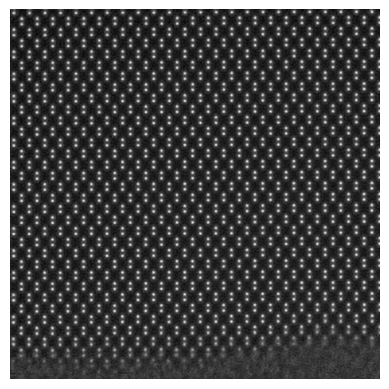

In [5]:
plt.imshow(np.angle(recon_object[:, :, 9]), cmap='gray')
plt.axis('off')

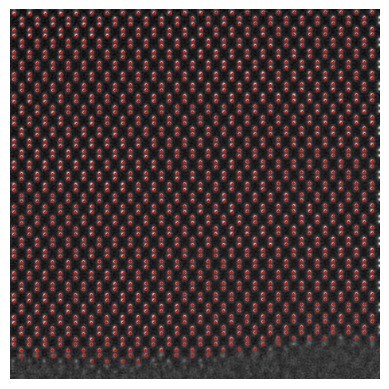

1459 columns found


In [6]:
LAYER = 9

image = np.angle(recon_object[:,:,LAYER])

blurred_image = gaussian_filter(image, 1)
distance = 2
threshold = 0.5

c0 = kemstem.find_columns(blurred_image, distance=distance, threshold=threshold)

plt.imshow(image, cmap='gray')
plt.axis('off')
plt.plot(c0[:, 1], c0[:, 0], 'r.', markersize=2)
plt.show()
print(f'{c0.shape[0]} columns found')

In [7]:
# test_it = 100
# window_dim = 5
# cf,errs,opts,data_fits = kemstem.refine_columns(blurred_image,c0[test_it,:],window_dim)

# visualization_window = 5*window_dim
# fig,ax = plt.subplots(2,2,constrained_layout=True)
# ax[0,0].matshow(data_fits[:,:,0,0],cmap='gray')
# ax[0,1].matshow(data_fits[:,:,0,1],cmap='gray')
# ax[1,0].matshow(blurred_image,cmap='gray')
# ax[1,0].plot(c0[test_it,1],c0[test_it,0],'b.') # original unfit position shown in blue
# ax[1,0].plot(cf[0,1],cf[0,0],'r.') # fit position shown in red
# ax[1,0].set_xlim([c0[test_it,1]-visualization_window,c0[test_it,1]+visualization_window])
# ax[1,0].set_ylim([c0[test_it,0]+visualization_window,c0[test_it,0]-visualization_window])
# ax[1,1].matshow(data_fits[:,:,0,0]-data_fits[:,:,0,1],cmap='gray',vmin=-.1,vmax=.1) # fit residual
# _ = [tax.axis('off') for tax in ax.ravel()]

In [8]:
# cf, errs, opts, data_fits = kemstem.refine_columns(image, c0, window_dim)

In [9]:
# plt.imshow(image, cmap='gray')
# plt.axis('off')
# plt.plot(cf[:, 1], cf[:, 0], 'r.', markersize=2)
# plt.show()
# print(f'Refined columns')

(np.float64(-0.5), np.float64(4.5), np.float64(4.5), np.float64(-0.5))

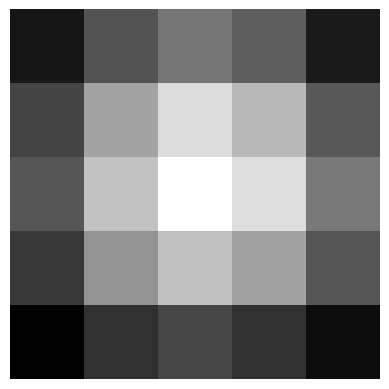

In [24]:
WINDOW = 2
cx, cy = c0[100]
wx_start, wx_end = cx-WINDOW, cx+WINDOW+1
wy_start, wy_end = cy-WINDOW, cy+WINDOW+1
plt.imshow(np.angle(recon_object)[wx_start:wx_end, wy_start:wy_end, LAYER], cmap='gray')
plt.axis('off')

In [26]:
columns = []

for i, (cx, cy) in enumerate(tqdm(c0)):
    wx_start, wx_end = cx-WINDOW, cx+WINDOW+1
    wy_start, wy_end = cy-WINDOW, cy+WINDOW+1
    column = np.angle(recon_object)[wx_start:wx_end, wy_start:wy_end, 1:].mean(axis=(0, 1))
    columns.append(column)

  0%|          | 0/1459 [00:00<?, ?it/s]

In [ ]:
def double_erf(x, p0, p1, p2, x0, h):
    return p0 * (erf(p2*(x - x0)) - erf(p2*(x - x0 - h))) + p1

In [72]:
popt

array([ 0.10500259,  0.06539792,  0.36327553,  1.0370373 , 13.67133075])

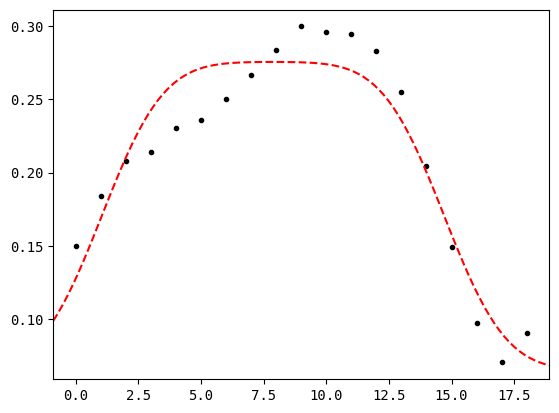

[ 0.10500329  0.06539737  0.3632672   1.03706733 13.67130114]


In [74]:
popt, _, _ = fit(
    double_erf, np.arange(len(columns[100])), columns[100], plot=True,
    p0=[-0.05, 0.05, 1, 1, 15],
    bounds=[[-1, -1, -10, -5, 0], [1, 1, 10, 5, 20]])
print(popt)


In [78]:
heights = []
heights_error = []

for column in columns:
    (_, _, _, x0, h), (_, _, _, dx0, dh), _ = fit(double_erf, np.arange(len(column)), column, plot=False,
                                                  p0=popt,
                                                  bounds=[[-1, -1, -10, -5, 0], [1, 1, 10, 5, 20]], maxfev=10000)
    heights.append(h)
    heights_error.append(dh)


(0.0, 20.0)

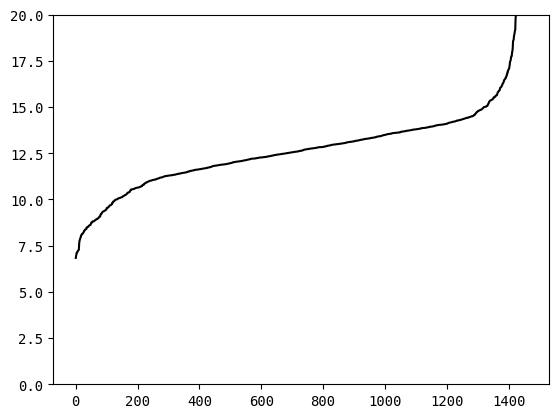

In [80]:
plt.plot(np.sort(heights), 'k')
plt.ylim(0, 20)

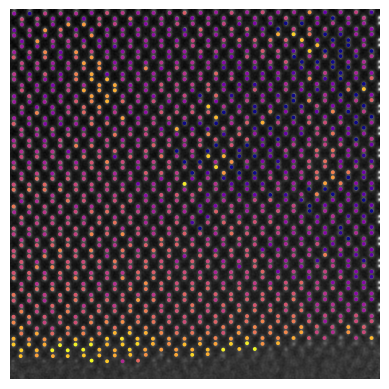

In [81]:
plt.imshow(np.angle(recon_object).sum(axis=-1), cmap='gray')
plt.axis('off')
plt.scatter(c0[:, 1], c0[:, 0], c=heights, s=3, cmap='plasma_r', vmin=7, vmax=17)
plt.show()